Tunnel shell built: 816 pts, 1616 cells
Bounds (x_min,x_max,y_min,y_max,z_min,z_max): BoundsTuple(x_min = -0.4921298027038574,
            x_max = 10.207869529724121,
            y_min =  0.0,
            y_max = 20.0,
            z_min =  0.0,
            z_max =  6.730000019073486)


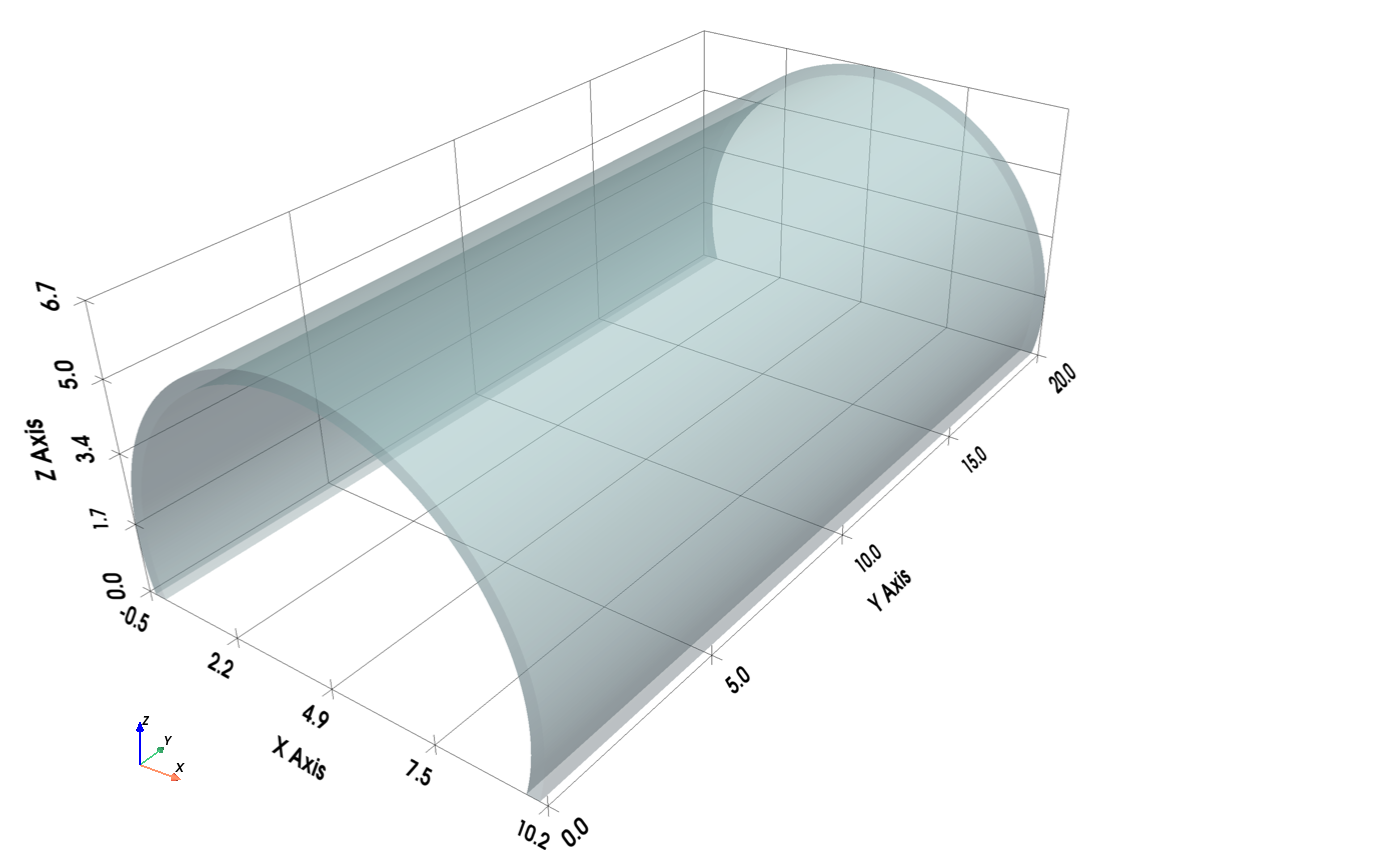

In [1]:
# Cell 1: Build tunnel shell + visualize
import numpy as np
import pyvista as pv

pv.set_jupyter_backend('static')

# --- Tunnel params (confirmed) ---
R_INNER = 5.05
T_LINING = 0.30
R_OUTER  = R_INNER + T_LINING
LENGTH_Y = 20.0
S_ARC    = 18.66
THETA_MAX = S_ARC / R_INNER
HALF_ANGLE = THETA_MAX / 2.0
CX = R_INNER * np.sin(HALF_ANGLE)  # ≈ 4.858
CZ = 1.380                         # fixed

def build_tunnel_shell(num_arc: int = 201) -> pv.PolyData:
    theta = np.linspace(-HALF_ANGLE, +HALF_ANGLE, num_arc)
    x_in = CX + R_INNER * np.sin(theta); z_in = CZ + R_INNER * np.cos(theta)
    x_out = CX + R_OUTER * np.sin(theta[::-1]); z_out = CZ + R_OUTER * np.cos(theta[::-1])

    inner = np.column_stack([x_in,  np.zeros_like(x_in),  z_in])
    outer = np.column_stack([x_out, np.zeros_like(x_out), z_out])
    section = np.vstack([inner, outer])

    faces = []
    n = num_arc
    for i in range(n - 1):
        j  = 2*n - 1 - i
        j1 = 2*n - 2 - i
        faces.extend([4, i, i+1, j1, j])

    profile = pv.PolyData(section, np.array(faces, dtype=np.int64))
    shell = profile.extrude((0, LENGTH_Y, 0), capping=True).clean().triangulate()
    # clip bottom at Z=0 (flat ground)
    shell = shell.clip(normal=(0,0,1), origin=(0,0,0), invert=False).clean().triangulate()
    return shell

tunnel_shell = build_tunnel_shell()
print("Tunnel shell built:", tunnel_shell.n_points, "pts,", tunnel_shell.n_cells, "cells")
print("Bounds (x_min,x_max,y_min,y_max,z_min,z_max):", tunnel_shell.bounds)

# --- visualize ---
p = pv.Plotter(window_size=[1400, 850])
p.add_mesh(tunnel_shell, opacity=0.35, show_edges=False)
p.add_axes(); p.show_grid()
p.camera_position = [(24,-15,20),(5,12,0),(0,0,1)]
p.enable_anti_aliasing('ssaa')
p.show()


Built 151 geometries from 152 instances.


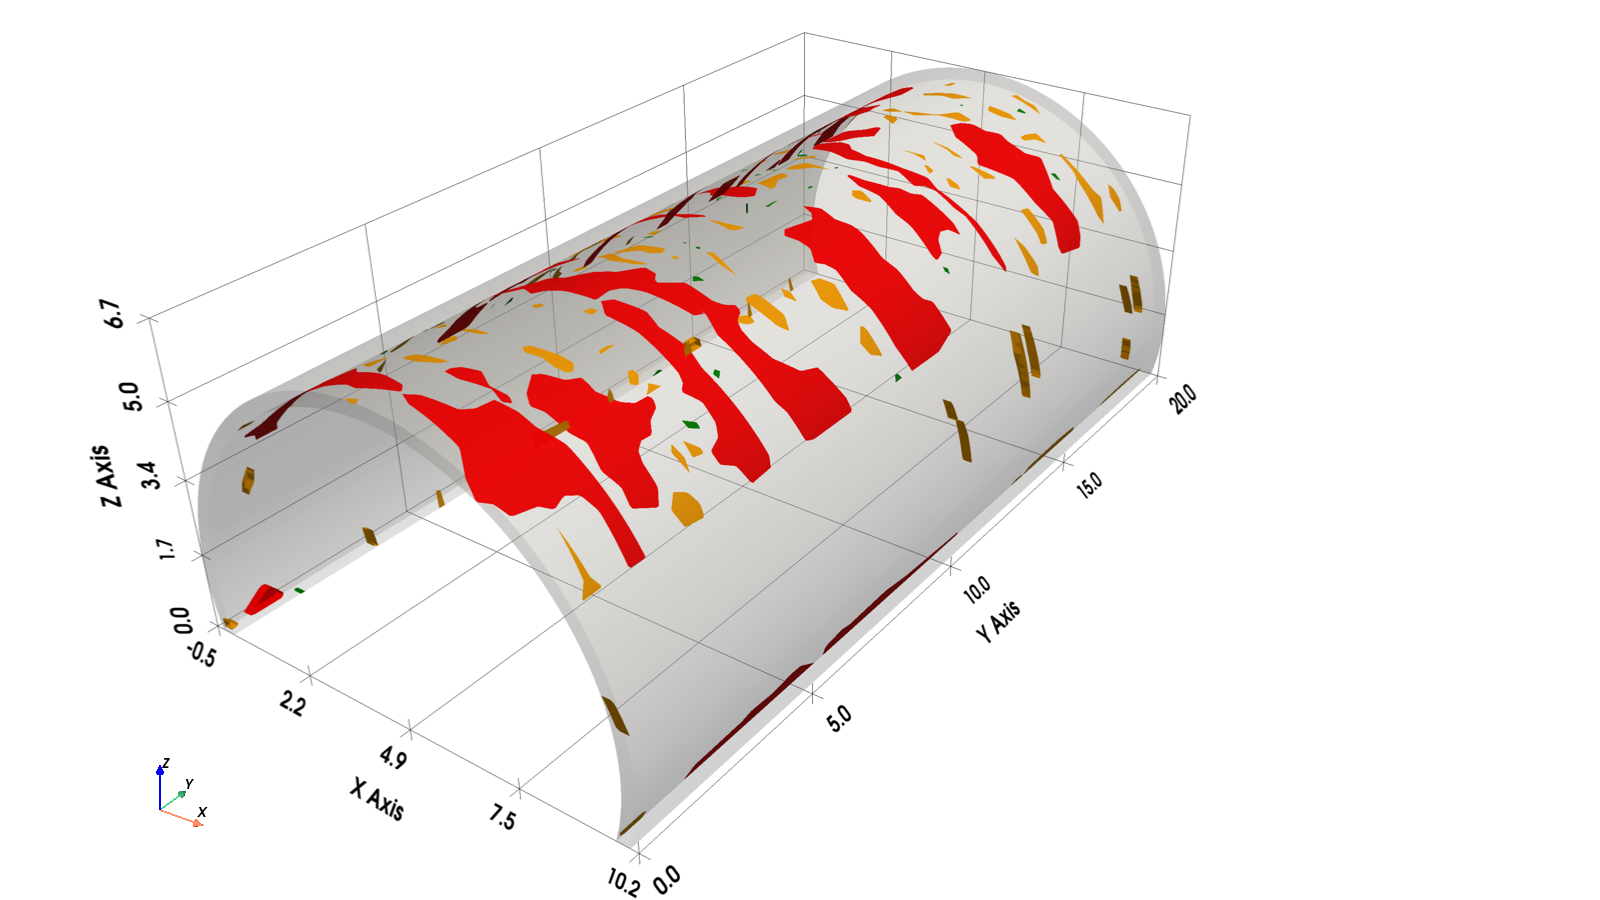

✅ Geometry ready: seepage=surface, others=solid (extruded by zone).


In [2]:
# Cell 2: Build ALL damage geometries on the cylinder (Poisson+Lloyd) + visualize
import numpy as np
import pandas as pd
import pyvista as pv
from matplotlib.path import Path as MplPath
from scipy.spatial import Voronoi

pv.set_jupyter_backend('static')

# ---- Cylinder params (must match Cell 1) ----
R_INNER = 5.05
T_LINING = 0.30
R_OUTER  = R_INNER + T_LINING
LENGTH_Y = 20.0
S_ARC    = 18.66
THETA_MAX = S_ARC / R_INNER
HALF_ANGLE = THETA_MAX / 2.0
CX = R_INNER * np.sin(HALF_ANGLE)
CZ = 1.380

# ---- Controls ----
TARGET_EDGE_FINE = 0.08   # m-equivalent target edge (after metric scaling)
LLOYD_ITERS      = 3
EXTRUDE_THICK    = 0.20
SEEPAGE_NAME     = "seepage"
CATEGORY_SOLID   = {"corrosion","damaged joint","spalling","crack"}
RISK_COLOR = {1:'red', 2:'orange', 3:'green'}

# ---- Mapping/projection ----
def world_to_uv(XYZ: np.ndarray) -> np.ndarray:
    ang = np.unwrap(np.arctan2(XYZ[:,0]-CX, XYZ[:,2]-CZ))
    return np.column_stack([ang, XYZ[:,1]])

def uv_to_world(uv: np.ndarray) -> np.ndarray:
    u, v = uv[:,0], uv[:,1]
    x = CX + R_INNER * np.sin(u)
    z = CZ + R_INNER * np.cos(u)
    y = v
    return np.column_stack([x,y,z])

def intersect_line_circle_xz(p, d, forward=True):
    x0,y0,z0 = p; dx,_,dz = d
    a = dx*dx + dz*dz
    if a == 0: return None
    b = 2*((x0-CX)*dx + (z0-CZ)*dz)
    c = (x0-CX)**2 + (z0-CZ)**2 - R_INNER**2
    disc = b*b - 4*a*c
    if disc < 0: return None
    sd = np.sqrt(disc)
    t1 = (-b - sd)/(2*a); t2 = (-b + sd)/(2*a)
    cand = []
    if forward:
        if t1>=0: cand.append(t1)
        if t2>=0: cand.append(t2)
    else:
        if t1<=0: cand.append(t1)
        if t2<=0: cand.append(t2)
    if not cand: return None
    t = min(cand, key=abs)
    return np.array([x0+t*dx, y0, z0+t*dz])

def radial_project_to_cylinder(p):
    x,y,z = p
    vx,vz = x-CX, z-CZ
    n = np.hypot(vx,vz)
    if n == 0: return np.array([CX, y, CZ+R_INNER])
    s = R_INNER/n
    return np.array([CX+vx*s, y, CZ+vz*s])

def project_point_by_zone(p, zone):
    z = (zone or 'c').lower()
    d = np.array([0.0,0.0,1.0]) if z=='c' else (np.array([-1.0,0.0,0.0]) if z=='l' else np.array([+1.0,0.0,0.0]))
    hit = intersect_line_circle_xz(p, d, forward=True)
    return hit if hit is not None else radial_project_to_cylinder(p)

# ---- UV tools ----
def polygon_area(poly):
    x,y = poly[:,0], poly[:,1]
    return 0.5*np.sum(x*np.roll(y,-1) - np.roll(x,-1)*y)

def ensure_closed_ccw(uv):
    uv = np.asarray(uv, float)
    if not np.allclose(uv[0], uv[-1]): uv = np.vstack([uv, uv[0]])
    if polygon_area(uv) < 0: uv = uv[::-1]
    return uv

def resample_uv_polyline_by_arclength(uv_closed, h, min_pts=24):
    uv = np.asarray(uv_closed, float)
    if not np.allclose(uv[0], uv[-1]): uv = np.vstack([uv, uv[0]])
    seg = np.linalg.norm(np.diff(uv, axis=0), axis=1)
    cum = np.insert(np.cumsum(seg), 0, 0.0)
    total = cum[-1]
    if total <= 0: return uv[:1]
    n = max(min_pts, int(np.ceil(total/max(h,1e-6))))
    targets, j = np.linspace(0, total, n, endpoint=False), 0
    res = []
    for t in targets:
        while j+1 < len(cum) and cum[j+1] < t: j += 1
        if j+1 >= len(cum): res.append(uv[-1]); break
        t0,t1 = cum[j], cum[j+1]
        w = 0 if t1==t0 else (t-t0)/(t1-t0)
        res.append(uv[j]*(1-w)+uv[j+1]*w)
    return np.array(res)

# ---- Poisson+Lloyd（物理度量：U'=R*u, V'=v）----
def poisson_points_in_polygon(uv_poly_m, r, k=40, seed=42):
    rng = np.random.default_rng(seed)
    path = MplPath(uv_poly_m)
    mn = uv_poly_m.min(axis=0); mx = uv_poly_m.max(axis=0)
    cell = r/np.sqrt(2)
    dims = np.ceil((mx-mn)/cell).astype(int)
    grid = -np.ones((dims[0]+1, dims[1]+1), dtype=int)
    samples = []; active = []
    def grid_coords(p): return ((p-mn)/cell).astype(int)
    def fits(p):
        if not path.contains_point(p): return False
        gi,gj = grid_coords(p)
        i0,i1 = max(gi-2,0), min(gi+3, grid.shape[0])
        j0,j1 = max(gj-2,0), min(gj+3, grid.shape[1])
        for ii in range(i0,i1):
            for jj in range(j0,j1):
                idx = grid[ii,jj]
                if idx >= 0 and np.linalg.norm(samples[idx]-p) < r:
                    return False
        return True
    for _ in range(1000):
        p0 = rng.uniform(mn, mx)
        if path.contains_point(p0):
            samples.append(p0); active.append(0)
            gi,gj = grid_coords(p0); grid[gi,gj]=0
            break
    if not samples: return np.empty((0,2))
    while active:
        idx = rng.integers(len(active))
        s_idx = active[idx]; s = samples[s_idx]
        accepted=False
        for _ in range(k):
            ang = rng.uniform(0, 2*np.pi)
            rad = rng.uniform(r, 2*r)
            p = s + rad*np.array([np.cos(ang), np.sin(ang)])
            if fits(p):
                samples.append(p)
                gi,gj = grid_coords(p); grid[gi,gj]=len(samples)-1
                active.append(len(samples)-1); accepted=True; break
        if not accepted: active.pop(idx)
    return np.array(samples)

def lloyd_relaxation(points_m, poly_m, iters=3):
    if len(points_m)==0 or iters<=0: return points_m
    poly_m = np.asarray(poly_m, float)
    bbox_min, bbox_max = poly_m.min(axis=0), poly_m.max(axis=0)
    for _ in range(iters):
        pad = 1.0
        corners = np.array([
            [bbox_min[0]-pad, bbox_min[1]-pad],
            [bbox_min[0]-pad, bbox_max[1]+pad],
            [bbox_max[0]+pad, bbox_min[1]-pad],
            [bbox_max[0]+pad, bbox_max[1]+pad],
        ])
        pts = np.vstack([points_m, corners])
        vor = Voronoi(pts)
        new_pts = []
        path = MplPath(poly_m)
        for i in range(len(points_m)):
            region_index = vor.point_region[i]
            region = vor.regions[region_index]
            if -1 in region or len(region)==0:
                new_pts.append(points_m[i]); continue
            verts = np.array([vor.vertices[v] for v in region])
            if np.any(np.isnan(verts)):
                new_pts.append(points_m[i]); continue
            inside = path.contains_points(verts)
            P = verts[inside]
            if len(P) < 3:
                new_pts.append(points_m[i]); continue
            c = P.mean(axis=0)
            new_pts.append(c if path.contains_point(c) else points_m[i])
        points_m = np.array(new_pts)
    return points_m

def triangulate_on_cylinder_uv_poisson(uv_closed, target_h, lloyd_iters=3):
    uv_closed = ensure_closed_ccw(uv_closed)
    uv_m = np.column_stack([R_INNER*uv_closed[:,0], uv_closed[:,1]])  # metric scaling
    uvb_m = resample_uv_polyline_by_arclength(uv_m, target_h, min_pts=24)
    uvb_m = ensure_closed_ccw(uvb_m)
    r = max(1e-6, target_h*0.80)
    uvi_m = poisson_points_in_polygon(uvb_m, r=r, k=40, seed=42)
    if len(uvi_m): uvi_m = lloyd_relaxation(uvi_m, uvb_m, iters=int(lloyd_iters))
    all_m = np.vstack([uvb_m, uvi_m]) if len(uvi_m) else uvb_m
    cloud = pv.PolyData(np.column_stack([all_m, np.zeros((len(all_m),1))]))
    tri2d = cloud.delaunay_2d()
    if tri2d.n_cells == 0: return None
    faces = tri2d.faces.reshape(-1,4)[:,1:4]
    verts_m = tri2d.points[:,:2]
    inside = MplPath(uvb_m).contains_points(np.mean(verts_m[faces], axis=1))
    faces_kept = faces[inside]
    if len(faces_kept)==0: return None
    uniq, remap = np.unique(faces_kept.ravel(), return_inverse=True)
    pts_kept_m = verts_m[uniq]
    faces_flat = np.column_stack([np.full(len(remap.reshape(-1,3)),3), remap.reshape(-1,3)]).ravel().astype(np.int64)
    uv_kept = np.column_stack([pts_kept_m[:,0]/R_INNER, pts_kept_m[:,1]])
    xyz = uv_to_world(uv_kept)
    return pv.PolyData(xyz, faces_flat).clean().triangulate()

def build_geom_from_meta(meta, target_edge=TARGET_EDGE_FINE, lloyd_iters=LLOYD_ITERS, thickness=EXTRUDE_THICK):
    pts = np.asarray(meta["points"], float)
    if len(pts) < 3: return None
    zone = (meta.get("zone") or "c").lower()
    cat  = (meta.get("category_name") or "").lower()

    proj = np.array([project_point_by_zone(p, zone) for p in pts])
    uv = world_to_uv(proj)
    uv_closed = uv if np.allclose(uv[0],uv[-1]) else np.vstack([uv, uv[0]])

    surface = triangulate_on_cylinder_uv_poisson(uv_closed, target_edge, lloyd_iters=lloyd_iters)
    if surface is None or surface.n_cells==0:
        return None

    if cat == SEEPAGE_NAME:
        return surface
    if zone == 'c': vec = (0.0, 0.0, +thickness)
    elif zone == 'l': vec = (-thickness, 0.0, 0.0)
    elif zone == 'r': vec = (+thickness, 0.0, 0.0)
    else: vec = (0.0, 0.0, +thickness)
    return surface.extrude(vec, capping=True).clean().triangulate()

# ---- Load instances (or reuse grouped_lists) ----
def load_instances(csv_path: str) -> list:
    df = pd.read_csv(csv_path)
    df['orig_index'] = np.arange(len(df))
    df_sorted = df.sort_values(by=['instance_id', 'orig_index'])
    grouped = []
    for inst_id, group in df_sorted.groupby('instance_id'):
        coords = group[['x','y','z']].values
        grouped.append({
            'instance_id': inst_id,
            'points': coords,
            'risk': group['risk'].iloc[0],
            'zone': (group['zone'].iloc[0] if 'zone' in group else 'c'),
            'category_name': group['category_name'].iloc[0],
            'area': group['area'].iloc[0] if 'area' in group else None
        })
    return grouped

try:
    grouped_lists  # from your earlier steps
    metas_source = grouped_lists
except NameError:
    metas_source = load_instances('3d_point_info_with_zones.csv')

# ---- Build all geoms ----
metas, geoms = [], []
for meta in metas_source:
    g = build_geom_from_meta(meta)
    if g is not None:
        metas.append(meta); geoms.append(g)

print(f"Built {len(geoms)} geometries from {len(metas_source)} instances.")

# ---- visualize on tunnel ----
try:
    tunnel_shell
except NameError:
    # minimal rebuild if Cell 1 hasn't run in this kernel
    theta = np.linspace(-HALF_ANGLE, +HALF_ANGLE, 201)
    x_in = CX + R_INNER * np.sin(theta); z_in = CZ + R_INNER * np.cos(theta)
    x_out = CX + R_OUTER * np.sin(theta[::-1]); z_out = CZ + R_OUTER * np.cos(theta[::-1])
    inner = np.column_stack([x_in,  np.zeros_like(x_in),  z_in])
    outer = np.column_stack([x_out, np.zeros_like(x_out), z_out])
    section = np.vstack([inner, outer])
    faces = []
    n = 201
    for i in range(n - 1):
        j  = 2*n - 1 - i; j1 = 2*n - 2 - i
        faces.extend([4, i, i+1, j1, j])
    profile = pv.PolyData(section, np.array(faces, dtype=np.int64))
    tunnel_shell = profile.extrude((0, LENGTH_Y, 0), capping=True).clean().triangulate().clip(
        normal=(0,0,1), origin=(0,0,0), invert=False).clean().triangulate()

p = pv.Plotter(window_size=[1600, 900])
p.add_mesh(tunnel_shell, color="lightgray", opacity=0.25, show_edges=False)

label_pts, label_txt = [], []
for meta, g in zip(metas, geoms):
    risk = meta.get('risk')
    color = RISK_COLOR.get(risk, 'gray')
    p.add_mesh(g, color=color, opacity=0.95)
    c = g.center
    label_pts.append(c)
    label_txt.append(f"#{meta['instance_id']} {meta['category_name']}")

if label_pts:
    p.add_point_labels(label_pts, label_txt, font_size=10,
                       shape_color='white', shape_opacity=0.7,
                       text_color='black', shape='rounded_rect', point_size=0)

p.add_axes(); p.show_grid()
p.camera_position=[(24,-15,20),(5,12,0),(0,0,1)]
p.enable_anti_aliasing('ssaa')
p.show()

print("✅ Geometry ready: seepage=surface, others=solid (extruded by zone).")


In [3]:
# Cell 3 ifc for visualization no void
import ifcopenshell
import uuid
from ifcopenshell.api import run  # use official API for Psets (guaranteed in BIM Vision)

OUT_IFC = "Tunnel_Damages_IFC4X3ADD2_NoVoid.ifc"
SEEPAGE_NAME = "seepage"
RISK_COLOR = {1:(1.0,0.0,0.0), 2:(1.0,0.5,0.0), 3:(0.0,0.6,0.0)}
DEFAULT_COLOR = (0.5,0.5,0.5)

def new_guid(): 
    return ifcopenshell.guid.compress(uuid.uuid4().hex)

def pv_to_tfs(ifc, mesh):
    tri = mesh.triangulate().clean()
    pts, farr = tri.points, tri.faces
    coord_list = [[float(x), float(y), float(z)] for x,y,z in pts]
    cpl = ifc.create_entity("IfcCartesianPointList3D")
    assigned = None
    for attr in ("CoordList","Coordinates","CoordLists"):
        if hasattr(cpl, attr):
            setattr(cpl, attr, coord_list); assigned = attr; break
    if assigned is None:
        raise RuntimeError("IfcCartesianPointList3D missing CoordList/Coordinates/CoordLists")

    coord_index, i = [], 0
    while i < len(farr):
        n = int(farr[i])
        if n == 3:
            a,b,c = int(farr[i+1])+1, int(farr[i+2])+1, int(farr[i+3])+1
            coord_index.append([a,b,c])
        i += n + 1

    return ifc.create_entity("IfcTriangulatedFaceSet", Coordinates=cpl, CoordIndex=coord_index, Closed=True)

def make_style(ifc, rgb, transparency=0.0):
    r,g,b = rgb
    col = ifc.create_entity("IfcColourRgb", Name=None, Red=r, Green=g, Blue=b)
    shading = ifc.create_entity("IfcSurfaceStyleShading", SurfaceColour=col, Transparency=float(transparency))
    return ifc.create_entity("IfcSurfaceStyle", Name="Style", Side="BOTH", Styles=[shading])

def styled_shape_rep(ifc, subctx, mesh, rgb=None, alpha=0.0):
    tfs = pv_to_tfs(ifc, mesh)
    if rgb is not None:
        style = make_style(ifc, rgb, alpha)
        ifc.create_entity("IfcStyledItem", Item=tfs, Styles=[style], Name=None)
    rep = ifc.create_entity(
        "IfcShapeRepresentation",
        ContextOfItems=subctx, RepresentationIdentifier="Body",
        RepresentationType="Tessellation", Items=[tfs]
    )
    return ifc.create_entity("IfcProductDefinitionShape", Representations=[rep]), tfs

def add_layer(ifc, name, items):
    if items:
        ifc.create_entity("IfcPresentationLayerAssignment", Name=name, AssignedItems=items)

# ---------- IFC bootstrap ----------
ifc = ifcopenshell.file(schema="IFC4X3_ADD2")

project = ifc.create_entity("IfcProject", GlobalId=new_guid(), Name="Tunnel Damage Export (All Proxy + Psets)")
u_len = ifc.create_entity("IfcSIUnit", UnitType="LENGTHUNIT", Name="METRE")
u_ang = ifc.create_entity("IfcSIUnit", UnitType="PLANEANGLEUNIT", Name="RADIAN")
project.UnitsInContext = ifc.create_entity("IfcUnitAssignment", Units=[u_len, u_ang])

context = ifc.create_entity(
    "IfcGeometricRepresentationContext",
    ContextIdentifier="Model", ContextType="Model",
    CoordinateSpaceDimension=3, Precision=1e-5,
    WorldCoordinateSystem=ifc.create_entity(
        "IfcAxis2Placement3D",
        Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0,0.0,0.0])
    )
)
body_ctx = ifc.create_entity(
    "IfcGeometricRepresentationSubContext",
    ContextIdentifier="Body", ContextType="Model", ParentContext=context
)

# Spatial: Facility / FacilityPart stand in for Tunnel / TunnelPart
site     = ifc.create_entity("IfcSite",     GlobalId=new_guid(), Name="Site")
facility = ifc.create_entity("IfcFacility", GlobalId=new_guid(), Name="Tunnel")
fac_part = ifc.create_entity("IfcFacilityPart", GlobalId=new_guid(), Name="Tunnel Section")
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=project,  RelatedObjects=[site])
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=site,     RelatedObjects=[facility])
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=facility, RelatedObjects=[fac_part])

# Host tunnel (independent reference; no subtraction)
try:
    tunnel_shell  # from Cell 1
    host_shape, host_tfs = styled_shape_rep(ifc, body_ctx, tunnel_shell, rgb=(0.8,0.8,0.8), alpha=0.25)
    host_place = ifc.create_entity("IfcLocalPlacement",
        RelativePlacement=ifc.create_entity("IfcAxis2Placement3D",
            Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0,0.0,0.0])))
    host_elem = ifc.create_entity("IfcBuildingElementProxy",
        GlobalId=new_guid(), Name="Tunnel Lining (Host)",
        ObjectPlacement=host_place, Representation=host_shape)
    ifc.create_entity("IfcRelContainedInSpatialStructure", GlobalId=new_guid(),
                      RelatedElements=[host_elem], RelatingStructure=fac_part)
except NameError:
    host_tfs = None

# Task (inspection)
task = ifc.create_entity("IfcTask", GlobalId=new_guid(),
                         Name="Inspection", Identification="INS-001",
                         Description="Tunnel damage inspection (digitisation)")
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=project, RelatedObjects=[task])

# Layers per category
title_map = {"corrosion":"Corrosion","damaged joint":"DamagedJoint","spalling":"Spalling","crack":"Crack","seepage":"Seepage"}
layer_items = { "Tunnel": ([host_tfs] if 'host_tfs' in locals() and host_tfs is not None else []),
                "Seepage": [], "Corrosion": [], "DamagedJoint": [], "Spalling": [], "Crack": [] }

# Instances (ALL proxies, including seepage)
all_elems = []
created = 0

for meta, mesh in zip(metas, geoms):
    cat  = (meta.get("category_name") or "").lower().strip()
    inst = meta.get("instance_id")
    risk = meta.get("risk")
    zone = meta.get("zone")
    area = meta.get("area")

    title = title_map.get(cat, "Damage")
    color = RISK_COLOR.get(risk, DEFAULT_COLOR)
    alpha = 0.5 if cat == SEEPAGE_NAME else 0.0

    prod_shape, tfs = styled_shape_rep(ifc, body_ctx, mesh, rgb=color, alpha=alpha)

    place = ifc.create_entity("IfcLocalPlacement",
        RelativePlacement=ifc.create_entity("IfcAxis2Placement3D",
            Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0,0.0,0.0])))

    # IMPORTANT: all as proxies (seepage too)
    obj_type = f"{title} (Surface)" if cat == SEEPAGE_NAME else f"{title} (Void-like)"
    elem = ifc.create_entity(
        "IfcBuildingElementProxy",
        GlobalId=new_guid(),
        Name=f"{title} #{inst}" if inst is not None else title,
        ObjectType=obj_type,
        Description=f"Category={title}; Risk={risk}; Zone={zone}; Area={area}",
        ObjectPlacement=place,
        Representation=prod_shape,
        Tag=f"ID={inst}"
    )

    ifc.create_entity("IfcRelContainedInSpatialStructure", GlobalId=new_guid(),
                      RelatedElements=[elem], RelatingStructure=fac_part)

    # Pset via official API
    pset = run("pset.add_pset", ifc, product=elem, name="Pset_DamageOccurrence")
    run("pset.edit_pset", ifc, pset=pset, properties={
        "InstanceId":   str(inst) if inst is not None else None,
        "RiskLevel":    int(risk) if risk is not None else None,
        "CategoryName": title,
        "Zone":         str(zone) if zone is not None else None,
        "Area":         float(area) if area is not None else None,
        "IsVoidLike":   (cat != SEEPAGE_NAME),
        "IsSurface":    (cat == SEEPAGE_NAME),
    })

    # layer assign
    layer_key = title if title in layer_items else "Damage"
    layer_items.setdefault(layer_key, []).append(tfs)

    all_elems.append(elem); created += 1

# Link to task
if all_elems:
    ifc.create_entity("IfcRelAssignsToProcess", GlobalId=new_guid(),
                      Name="Inspection-ObservedDamages",
                      RelatingProcess=task, RelatedObjects=all_elems)

# Create layers
for lname, items in layer_items.items():
    add_layer(ifc, lname, items)

# Write IFC
ifc.write(OUT_IFC)
print(f"🎉 IFC exported: {OUT_IFC}")
print(f"   Elements: {created} (ALL IfcBuildingElementProxy; seepage marked as surface via ObjectType/Pset)")
print("   Properties visible in BIM Vision: Name/ObjectType/Description/Tag + Pset_DamageOccurrence.")


🎉 IFC exported: Tunnel_Damages_IFC4X3ADD2_NoVoid.ifc
   Elements: 151 (ALL IfcBuildingElementProxy; seepage marked as surface via ObjectType/Pset)
   Properties visible in BIM Vision: Name/ObjectType/Description/Tag + Pset_DamageOccurrence.


In [4]:
# Cell 3: All damages as IfcBuildingElementProxy (independent & visible),
#         PLUS a hidden IfcVoidingFeature for non-seepage to subtract host,
#         with FULL Psets via ifcopenshell.api

import ifcopenshell
import uuid
from ifcopenshell.api import run  # official API for robust Pset writing (recommended)

OUT_IFC = "Tunnel_Damages_IFC4X3ADD2_WithVoid.ifc"

SEEPAGE_NAME = "seepage"
RISK_COLOR = {1:(1.0,0.0,0.0), 2:(1.0,0.5,0.0), 3:(0.0,0.6,0.0)}
DEFAULT_COLOR = (0.5,0.5,0.5)

def new_guid():
    return ifcopenshell.guid.compress(uuid.uuid4().hex)

def pv_to_tfs(ifc, mesh):
    tri = mesh.triangulate().clean()
    pts, farr = tri.points, tri.faces
    coord_list = [[float(x), float(y), float(z)] for x, y, z in pts]
    cpl = ifc.create_entity("IfcCartesianPointList3D")
    assigned = None
    for attr in ("CoordList", "Coordinates", "CoordLists"):
        if hasattr(cpl, attr):
            setattr(cpl, attr, coord_list); assigned = attr; break
    if assigned is None:
        raise RuntimeError("IfcCartesianPointList3D missing CoordList/Coordinates/CoordLists")

    coord_index = []
    i = 0
    while i < len(farr):
        n = int(farr[i])
        if n == 3:
            a, b, c = int(farr[i+1])+1, int(farr[i+2])+1, int(farr[i+3])+1
            coord_index.append([a, b, c])
        i += n + 1

    return ifc.create_entity("IfcTriangulatedFaceSet", Coordinates=cpl, CoordIndex=coord_index, Closed=True)

def make_style(ifc, rgb, transparency=0.0):
    r, g, b = rgb
    col = ifc.create_entity("IfcColourRgb", Name=None, Red=r, Green=g, Blue=b)
    shading = ifc.create_entity("IfcSurfaceStyleShading", SurfaceColour=col, Transparency=float(transparency))
    return ifc.create_entity("IfcSurfaceStyle", Name="Style", Side="BOTH", Styles=[shading])

def styled_shape_rep(ifc, subctx, mesh, rgb=None, alpha=0.0):
    """Returns (IfcProductDefinitionShape, IfcTriangulatedFaceSet)"""
    tfs = pv_to_tfs(ifc, mesh)
    if rgb is not None:
        style = make_style(ifc, rgb, alpha)
        ifc.create_entity("IfcStyledItem", Item=tfs, Styles=[style], Name=None)
    rep = ifc.create_entity(
        "IfcShapeRepresentation",
        ContextOfItems=subctx,
        RepresentationIdentifier="Body",
        RepresentationType="Tessellation",
        Items=[tfs]
    )
    return ifc.create_entity("IfcProductDefinitionShape", Representations=[rep]), tfs

def add_layer(ifc, name, items):
    if items:
        ifc.create_entity("IfcPresentationLayerAssignment", Name=name, AssignedItems=items)

# ---------- IFC bootstrap ----------
ifc = ifcopenshell.file(schema="IFC4X3_ADD2")

project = ifc.create_entity("IfcProject", GlobalId=new_guid(), Name="Tunnel Damage Export (AllProxy+Voids+Psets)")
u_len = ifc.create_entity("IfcSIUnit", UnitType="LENGTHUNIT", Name="METRE")
u_ang = ifc.create_entity("IfcSIUnit", UnitType="PLANEANGLEUNIT", Name="RADIAN")
project.UnitsInContext = ifc.create_entity("IfcUnitAssignment", Units=[u_len, u_ang])

context = ifc.create_entity(
    "IfcGeometricRepresentationContext",
    ContextIdentifier="Model", ContextType="Model",
    CoordinateSpaceDimension=3, Precision=1e-5,
    WorldCoordinateSystem=ifc.create_entity(
        "IfcAxis2Placement3D",
        Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0, 0.0, 0.0])
    )
)
body_ctx = ifc.create_entity(
    "IfcGeometricRepresentationSubContext",
    ContextIdentifier="Body", ContextType="Model", ParentContext=context
)

# Spatial: Facility / FacilityPart stand in for Tunnel / TunnelPart
site     = ifc.create_entity("IfcSite",     GlobalId=new_guid(), Name="Site")
facility = ifc.create_entity("IfcFacility", GlobalId=new_guid(), Name="Tunnel")
fac_part = ifc.create_entity("IfcFacilityPart", GlobalId=new_guid(), Name="Tunnel Section")
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=project,  RelatedObjects=[site])
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=site,     RelatedObjects=[facility])
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=facility, RelatedObjects=[fac_part])

# ---- Host tunnel element (reference & subtraction target) ----
try:
    tunnel_shell  # from Cell 1
except NameError:
    raise RuntimeError("Host tunnel_shell not found. Run Cell 1 first.")

host_shape, host_tfs = styled_shape_rep(ifc, body_ctx, tunnel_shell, rgb=(0.8, 0.8, 0.8), alpha=0.25)
host_place = ifc.create_entity(
    "IfcLocalPlacement",
    RelativePlacement=ifc.create_entity(
        "IfcAxis2Placement3D",
        Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0, 0.0, 0.0])
    )
)
host_elem = ifc.create_entity(
    "IfcBuildingElementProxy",
    GlobalId=new_guid(),
    Name="Tunnel Lining (Host)",
    ObjectPlacement=host_place,
    Representation=host_shape
)
ifc.create_entity(
    "IfcRelContainedInSpatialStructure",
    GlobalId=new_guid(),
    RelatedElements=[host_elem],
    RelatingStructure=fac_part
)

# Task (one inspection covering all damages)
task = ifc.create_entity(
    "IfcTask",
    GlobalId=new_guid(),
    Name="Inspection",
    Identification="INS-001",
    Description="Tunnel damage inspection (digitisation)"
)
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=project, RelatedObjects=[task])

# Layers
title_map = {"corrosion":"Corrosion","damaged joint":"DamagedJoint","spalling":"Spalling","crack":"Crack","seepage":"Seepage"}
layer_items = {
    "Tunnel": [host_tfs],
    "Seepage": [], "Corrosion": [], "DamagedJoint": [], "Spalling": [], "Crack": [],
    "Voids(Hidden)": []  # optional: keep void geometry grouped (we'll not show them)
}

# ---- Export instances: ALL visible as Proxy; non-seepage also create hidden void to subtract host ----
all_for_task = []
created_proxy = 0
created_voids = 0

for meta, mesh in zip(metas, geoms):
    cat  = (meta.get("category_name") or "").lower().strip()
    inst = meta.get("instance_id")
    risk = meta.get("risk")
    zone = meta.get("zone")
    area = meta.get("area")

    title = title_map.get(cat, "Damage")
    color = RISK_COLOR.get(risk, DEFAULT_COLOR)
    alpha = 0.5 if cat == SEEPAGE_NAME else 0.0

    # 1) Visible BuildingElementProxy (independent)
    proxy_shape, proxy_tfs = styled_shape_rep(ifc, body_ctx, mesh, rgb=color, alpha=alpha)
    place = ifc.create_entity(
        "IfcLocalPlacement",
        RelativePlacement=ifc.create_entity(
            "IfcAxis2Placement3D",
            Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0, 0.0, 0.0])
        )
    )
    obj_type = f"{title} (Surface)" if cat == SEEPAGE_NAME else f"{title} (Void-like)"
    elem_proxy = ifc.create_entity(
        "IfcBuildingElementProxy",
        GlobalId=new_guid(),
        Name=f"{title} #{inst}" if inst is not None else title,
        ObjectType=obj_type,
        Description=f"Category={title}; Risk={risk}; Zone={zone}; Area={area}",
        ObjectPlacement=place,
        Representation=proxy_shape,
        Tag=f"ID={inst}"
    )
    ifc.create_entity(
        "IfcRelContainedInSpatialStructure",
        GlobalId=new_guid(),
        RelatedElements=[elem_proxy],
        RelatingStructure=fac_part
    )
    # Psets on visible proxy (will show in BIM Vision)
    pset = run("pset.add_pset", ifc, product=elem_proxy, name="Pset_DamageOccurrence")
    run("pset.edit_pset", ifc, pset=pset, properties={
        "InstanceId":   str(inst) if inst is not None else None,
        "RiskLevel":    int(risk) if risk is not None else None,
        "CategoryName": title,
        "Zone":         str(zone) if zone is not None else None,
        "Area":         float(area) if area is not None else None,
        "IsSurface":    (cat == SEEPAGE_NAME),
        "IsVoidLike":   (cat != SEEPAGE_NAME),
    })
    all_for_task.append(elem_proxy)
    created_proxy += 1

    # Layer for proxies
    key = title if title in layer_items else "Damage"
    layer_items.setdefault(key, []).append(proxy_tfs)

    # 2) For non-seepage: create a HIDDEN VoidingFeature to subtract host
    if cat != SEEPAGE_NAME:
        # Void uses same mesh; style fully transparent / or no style
        void_shape, void_tfs = styled_shape_rep(ifc, body_ctx, mesh, rgb=None, alpha=0.0)
        void_place = ifc.create_entity(
            "IfcLocalPlacement",
            RelativePlacement=ifc.create_entity(
                "IfcAxis2Placement3D",
                Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0, 0.0, 0.0])
            )
        )
        elem_void = ifc.create_entity(
            "IfcVoidingFeature",
            GlobalId=new_guid(),
            Name=f"{title} (Void for Host) #{inst}" if inst is not None else f"{title} (Void for Host)",
            ObjectType=title,
            Description=f"Subtractive feature paired with Proxy #{inst}",
            ObjectPlacement=void_place,
            Representation=void_shape
        )
        # Do NOT spatial-contain the void; only connect via Voids relation
        ifc.create_entity(
            "IfcRelVoidsElement",
            GlobalId=new_guid(),
            RelatingBuildingElement=host_elem,
            RelatedOpeningElement=elem_void
        )
        # (Optional) also attach minimal Pset to void for traceability
        try:
            pset_v = run("pset.add_pset", ifc, product=elem_void, name="Pset_DamageVoid")
            run("pset.edit_pset", ifc, pset=pset_v, properties={
                "RefInstanceId": str(inst) if inst is not None else None,
                "CategoryName":  title,
                "PairedProxy":   elem_proxy.GlobalId
            })
        except Exception:
            pass
        # layer group for debug (usually keep hidden in viewer)
        layer_items["Voids(Hidden)"].append(void_tfs)
        created_voids += 1

# Link proxies to inspection task
if all_for_task:
    ifc.create_entity(
        "IfcRelAssignsToProcess",
        GlobalId=new_guid(),
        Name="Inspection-ObservedDamages",
        RelatingProcess=task,
        RelatedObjects=all_for_task
    )

# Create layers
for lname, items in layer_items.items():
    add_layer(ifc, lname, items)

# Write IFC
ifc.write(OUT_IFC)
print(f"🎉 IFC exported: {OUT_IFC}")
print(f"   Visible Proxies: {created_proxy}  |  Hidden Voids (subtract host): {created_voids}")
print("   All damages are IfcBuildingElementProxy (independent visibility).")
print("   Non-seepage also create a hidden IfcVoidingFeature to cut the tunnel via IfcRelVoidsElement.")
print("   Full properties written on proxies under Pset_DamageOccurrence.")


🎉 IFC exported: Tunnel_Damages_IFC4X3ADD2_WithVoid.ifc
   Visible Proxies: 151  |  Hidden Voids (subtract host): 15
   All damages are IfcBuildingElementProxy (independent visibility).
   Non-seepage also create a hidden IfcVoidingFeature to cut the tunnel via IfcRelVoidsElement.
   Full properties written on proxies under Pset_DamageOccurrence.


In [5]:
# Cell 3 (Damage-only IFC): Export ONLY damage instances as IfcBuildingElementProxy
# - No tunnel element
# - All categories (including seepage) are independent proxies
# - Full Pset via ifcopenshell.api
# - Presentation layers per category for quick filtering

import ifcopenshell
import uuid
from ifcopenshell.api import run  # for robust Pset writing

OUT_IFC = "Tunnel_Damages_IFC4X3ADD2_DamageOnly.ifc"
SEEPAGE_NAME = "seepage"

# risk->rgb for styled items
RISK_COLOR = {1:(1.0,0.0,0.0), 2:(1.0,0.5,0.0), 3:(0.0,0.6,0.0)}
DEFAULT_COLOR = (0.5,0.5,0.5)

TITLE_MAP = {
    "corrosion": "Corrosion",
    "damaged joint": "DamagedJoint",
    "spalling": "Spalling",
    "crack": "Crack",
    "seepage": "Seepage",
}

def new_guid() -> str:
    return ifcopenshell.guid.compress(uuid.uuid4().hex)

def pv_to_tfs(ifc, mesh):
    tri = mesh.triangulate().clean()
    pts, farr = tri.points, tri.faces
    coord_list = [[float(x), float(y), float(z)] for x, y, z in pts]
    cpl = ifc.create_entity("IfcCartesianPointList3D")
    assigned = None
    for attr in ("CoordList", "Coordinates", "CoordLists"):
        if hasattr(cpl, attr):
            setattr(cpl, attr, coord_list); assigned = attr; break
    if assigned is None:
        raise RuntimeError("IfcCartesianPointList3D missing CoordList/Coordinates/CoordLists")

    coord_index = []
    i = 0
    while i < len(farr):
        n = int(farr[i])
        if n == 3:
            a, b, c = int(farr[i+1])+1, int(farr[i+2])+1, int(farr[i+3])+1
            coord_index.append([a, b, c])
        i += n + 1

    return ifc.create_entity("IfcTriangulatedFaceSet", Coordinates=cpl, CoordIndex=coord_index, Closed=True)

def make_style(ifc, rgb, transparency=0.0):
    r, g, b = rgb
    col = ifc.create_entity("IfcColourRgb", Name=None, Red=r, Green=g, Blue=b)
    shading = ifc.create_entity("IfcSurfaceStyleShading", SurfaceColour=col, Transparency=float(transparency))
    return ifc.create_entity("IfcSurfaceStyle", Name="Style", Side="BOTH", Styles=[shading])

def styled_shape_rep(ifc, subctx, mesh, rgb=None, alpha=0.0):
    """Return (IfcProductDefinitionShape, IfcTriangulatedFaceSet)"""
    tfs = pv_to_tfs(ifc, mesh)
    if rgb is not None:
        style = make_style(ifc, rgb, alpha)
        ifc.create_entity("IfcStyledItem", Item=tfs, Styles=[style], Name=None)
    rep = ifc.create_entity(
        "IfcShapeRepresentation",
        ContextOfItems=subctx,
        RepresentationIdentifier="Body",
        RepresentationType="Tessellation",
        Items=[tfs]
    )
    return ifc.create_entity("IfcProductDefinitionShape", Representations=[rep]), tfs

def add_layer(ifc, name, items):
    if items:
        ifc.create_entity("IfcPresentationLayerAssignment", Name=name, AssignedItems=items)

# ---------- IFC bootstrap ----------
ifc = ifcopenshell.file(schema="IFC4X3_ADD2")

project = ifc.create_entity("IfcProject", GlobalId=new_guid(), Name="Tunnel Damage Export (DamageOnly)")
u_len = ifc.create_entity("IfcSIUnit", UnitType="LENGTHUNIT", Name="METRE")
u_ang = ifc.create_entity("IfcSIUnit", UnitType="PLANEANGLEUNIT", Name="RADIAN")
project.UnitsInContext = ifc.create_entity("IfcUnitAssignment", Units=[u_len, u_ang])

context = ifc.create_entity(
    "IfcGeometricRepresentationContext",
    ContextIdentifier="Model", ContextType="Model",
    CoordinateSpaceDimension=3, Precision=1e-5,
    WorldCoordinateSystem=ifc.create_entity(
        "IfcAxis2Placement3D",
        Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0, 0.0, 0.0])
    )
)
body_ctx = ifc.create_entity(
    "IfcGeometricRepresentationSubContext",
    ContextIdentifier="Body", ContextType="Model", ParentContext=context
)

# Spatial: Facility / FacilityPart (作为容器，无隧道实体)
site     = ifc.create_entity("IfcSite",     GlobalId=new_guid(), Name="Site")
facility = ifc.create_entity("IfcFacility", GlobalId=new_guid(), Name="Tunnel")
fac_part = ifc.create_entity("IfcFacilityPart", GlobalId=new_guid(), Name="Tunnel Section")
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=project,  RelatedObjects=[site])
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=site,     RelatedObjects=[facility])
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=facility, RelatedObjects=[fac_part])

# Inspection Task
task = ifc.create_entity(
    "IfcTask",
    GlobalId=new_guid(),
    Name="Inspection",
    Identification="INS-001",
    Description="Tunnel damage inspection (digitisation)"
)
ifc.create_entity("IfcRelAggregates", GlobalId=new_guid(), RelatingObject=project, RelatedObjects=[task])

# ----- Build damage-only elements -----
layer_items = {"Seepage": [], "Corrosion": [], "DamagedJoint": [], "Spalling": [], "Crack": []}
all_elems = []
created = 0

# metas, geoms are expected from Cell 2
for meta, mesh in zip(metas, geoms):
    cat  = (meta.get("category_name") or "").lower().strip()
    inst = meta.get("instance_id")
    risk = meta.get("risk")
    zone = meta.get("zone")
    area = meta.get("area")

    title = TITLE_MAP.get(cat, "Damage")
    color = RISK_COLOR.get(risk, DEFAULT_COLOR)
    alpha = 0.5 if cat == SEEPAGE_NAME else 0.0

    prod_shape, tfs = styled_shape_rep(ifc, body_ctx, mesh, rgb=color, alpha=alpha)

    place = ifc.create_entity(
        "IfcLocalPlacement",
        RelativePlacement=ifc.create_entity(
            "IfcAxis2Placement3D",
            Location=ifc.create_entity("IfcCartesianPoint", Coordinates=[0.0, 0.0, 0.0])
        )
    )
    obj_type = f"{title} (Surface)" if cat == SEEPAGE_NAME else f"{title} (Void-like)"
    name_str = f"{title} #{inst}" if inst is not None else title
    desc_str = f"Category={title}; Risk={risk}; Zone={zone}; Area={area}"
    tag_str  = f"ID={inst}"

    elem = ifc.create_entity(
        "IfcBuildingElementProxy",
        GlobalId=new_guid(),
        Name=name_str,
        ObjectType=obj_type,
        Description=desc_str,
        ObjectPlacement=place,
        Representation=prod_shape,
        Tag=tag_str
    )

    # Spatial containment into FacilityPart
    ifc.create_entity(
        "IfcRelContainedInSpatialStructure",
        GlobalId=new_guid(),
        RelatedElements=[elem],
        RelatingStructure=fac_part
    )

    # Property set on the element (BIM Vision 可见)
    pset = run("pset.add_pset", ifc, product=elem, name="Pset_DamageOccurrence")
    run("pset.edit_pset", ifc, pset=pset, properties={
        "InstanceId":   str(inst) if inst is not None else None,
        "RiskLevel":    int(risk) if risk is not None else None,
        "CategoryName": title,
        "Zone":         str(zone) if zone is not None else None,
        "Area":         float(area) if area is not None else None,
        "IsSurface":    (cat == SEEPAGE_NAME),
        "IsVoidLike":   (cat != SEEPAGE_NAME),
    })

    # Collect for task relation and layers
    all_elems.append(elem); created += 1
    layer_key = title if title in layer_items else "Damage"
    layer_items.setdefault(layer_key, []).append(tfs)

# Link damages to the inspection task
if all_elems:
    ifc.create_entity(
        "IfcRelAssignsToProcess",
        GlobalId=new_guid(),
        Name="Inspection-ObservedDamages",
        RelatingProcess=task,
        RelatedObjects=all_elems
    )

# Create layers for quick filtering
for lname, items in layer_items.items():
    add_layer(ifc, lname, items)

# Write IFC
ifc.write(OUT_IFC)
print(f"🎉 IFC exported (damage-only): {OUT_IFC}")
print(f"   Elements: {created} (ALL IfcBuildingElementProxy; seepage marked as surface via ObjectType/Pset)")
print("   No tunnel element included; spatial container = IfcFacility/IfcFacilityPart.")


🎉 IFC exported (damage-only): Tunnel_Damages_IFC4X3ADD2_DamageOnly.ifc
   Elements: 151 (ALL IfcBuildingElementProxy; seepage marked as surface via ObjectType/Pset)
   No tunnel element included; spatial container = IfcFacility/IfcFacilityPart.
